<a href="https://colab.research.google.com/github/ingkapat/Thai-Scam-Call-Detector/blob/main/experiment2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# === Section 0: Install dependencies ===
!pip install -q transformers torchaudio librosa soundfile scikit-learn seaborn

In [4]:
# === Section 0: Mount Drive ===
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# === Section 0: Imports + Global Config ===
import os, json, time, glob, warnings, gc, re
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import librosa

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, roc_auc_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DRIVE_BASE      = '/content/drive/MyDrive/ThaiScamCall'
REAL_AUDIO_DIR  = f'{DRIVE_BASE}/real_audio'
OUT_DIR         = f'{DRIVE_BASE}/runs/experiment2'
TEXT_CLEAN      = f'{DRIVE_BASE}/models/phayathai_scam'
WHISPER_CLEAN   = f'{DRIVE_BASE}/models/whisper_enc_scam'

os.makedirs(REAL_AUDIO_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = ['not_scam', 'scam']
SR = 16000
CHUNK_SEC = 5         # ⭐ stream 5 วินาทีต่อรอบ
MAX_AUDIO_SEC = 30    # Whisper limit สำหรับ E2E
TEST_SET_F1 = {'two_stage': 0.9958, 'e2e': 0.9901}

print(f'✅ Setup OK')
print(f'   Chunk size: {CHUNK_SEC}s/รอบ — context จะสะสมเป็น 5, 10, 15, 20, 25, 30s...')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
✅ Setup OK
   Chunk size: 5s/รอบ — context จะสะสมเป็น 5, 10, 15, 20, 25, 30s...


In [6]:
# === Section 1: Auto-create metadata.csv ===
audio_files = sorted([f for f in os.listdir(REAL_AUDIO_DIR)
                      if f.endswith(('.mp3', '.wav', '.m4a'))])
assert audio_files, f'❌ ไม่มีไฟล์เสียงใน {REAL_AUDIO_DIR}'

def detect_label(fn):
    fn_lower = fn.lower()
    if 'notscam' in fn_lower or 'not_scam' in fn_lower: return 0
    if 'scam' in fn_lower: return 1
    return None

meta = pd.DataFrame([{
    'filename': f, 'label': detect_label(f),
    'speaker':  'tiktok', 'source': 'tiktok',
} for f in audio_files])

assert meta.label.notna().all(), '❌ มีไฟล์ที่ detect label ไม่ได้'
meta['label'] = meta.label.astype(int)
meta.to_csv(f'{REAL_AUDIO_DIR}/metadata.csv', index=False)

# Duration check
durations = []
for fn in meta.filename:
    try:
        durations.append(librosa.get_duration(path=f'{REAL_AUDIO_DIR}/{fn}'))
    except Exception as e:
        print(f'❌ {fn}: {e}')
        durations.append(None)
meta['duration'] = durations
meta['n_rounds'] = (meta.duration / CHUNK_SEC).astype(int)

print(f'Total: {len(meta)} files')
print(meta.label.value_counts().rename({0: 'not_scam', 1: 'scam'}))
print()
print(meta[['filename', 'label', 'duration', 'n_rounds']].to_string(index=False))

# Filter ไฟล์สั้นเกิน
meta = meta[meta.duration >= CHUNK_SEC].reset_index(drop=True)
print(f'\n✅ พร้อมใช้: {len(meta)} ไฟล์')

Total: 5 files
label
scam        4
not_scam    1
Name: count, dtype: int64

        filename  label   duration  n_rounds
rw_notscam03.mp3      0  30.375692         6
   rw_scam02.mp3      1 636.244875       127
   rw_scam03.mp3      1 210.222381        42
   rw_scam04.mp3      1  76.089229        15
   rw_scam06.mp3      1  60.000363        12

✅ พร้อมใช้: 5 ไฟล์


In [7]:
# === Section 2: Load 3 models ===
from transformers import (AutoProcessor, AutoModelForSpeechSeq2Seq,
                          AutoTokenizer, AutoModelForSequenceClassification,
                          AutoFeatureExtractor, AutoModelForAudioClassification)

ASR_MODEL_ID = 'biodatlab/whisper-th-medium-combined'

asr_processor = AutoProcessor.from_pretrained(ASR_MODEL_ID)
asr_model = AutoModelForSpeechSeq2Seq.from_pretrained(
    ASR_MODEL_ID, torch_dtype=torch.float16 if device == 'cuda' else torch.float32
).to(device).eval()
asr_forced_ids = asr_processor.get_decoder_prompt_ids(language='th', task='transcribe')
print('✅ ASR loaded')

text_tok = AutoTokenizer.from_pretrained(TEXT_CLEAN)
text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_CLEAN).to(device).eval()
print('✅ Text classifier loaded')

whisper_fe = AutoFeatureExtractor.from_pretrained(WHISPER_CLEAN)
whisper_model = AutoModelForAudioClassification.from_pretrained(WHISPER_CLEAN).to(device).eval()
print('✅ Whisper E2E loaded')

preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

✅ ASR loaded


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Text classifier loaded


Loading weights:   0%|          | 0/191 [00:00<?, ?it/s]

✅ Whisper E2E loaded


In [8]:
# === Section 3: Basic inference + streaming/growing ===

@torch.no_grad()
def asr_transcribe(audio_chunk, sr=SR):
    inputs = asr_processor(audio_chunk, sampling_rate=sr, return_tensors='pt')
    inputs = {k: v.to(device, dtype=asr_model.dtype if v.dtype == torch.float32 else v.dtype)
              for k, v in inputs.items()}
    gen = asr_model.generate(**inputs, forced_decoder_ids=asr_forced_ids, max_new_tokens=128)
    return asr_processor.batch_decode(gen, skip_special_tokens=True)[0]

@torch.no_grad()
def text_classify(text):
    enc = text_tok(text, truncation=True, max_length=256, return_tensors='pt').to(device)
    logits = text_model(**enc).logits
    return torch.softmax(logits, dim=-1).cpu().numpy()[0]

@torch.no_grad()
def whisper_classify(audio_chunk, sr=SR):
    inputs = whisper_fe(audio_chunk, sampling_rate=sr, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    logits = whisper_model(**inputs).logits
    return torch.softmax(logits, dim=-1).cpu().numpy()[0]


# Two-stage Streaming Concat — ASR new 5s chunk + accumulate text
def predict_two_stage_streaming(audio_path, chunk_sec=CHUNK_SEC, max_text_len=2000, sr=SR):
    wav, _ = librosa.load(audio_path, sr=sr)
    duration = len(wav) / sr
    accumulated_text = ''
    rows = []
    for round_idx, start in enumerate(np.arange(0, duration - chunk_sec + 0.1, chunk_sec)):
        chunk = wav[int(start*sr):int((start+chunk_sec)*sr)]
        t0 = time.time()
        new_text = asr_transcribe(chunk)                # ASR เฉพาะ 5s ใหม่
        accumulated_text = (accumulated_text + ' ' + new_text).strip()
        if len(accumulated_text) > max_text_len:
            accumulated_text = accumulated_text[-max_text_len:]
        prob = text_classify(accumulated_text)           # classify ทั้ง context
        rows.append({
            'round':       round_idx + 1,
            'context_sec': float(start + chunk_sec),     # context สะสม
            'prob_scam':   float(prob[1]),
            'pred':        int(prob[1] > 0.5),
            'latency':     time.time() - t0,
            'transcript':  accumulated_text[:300],
        })
    return pd.DataFrame(rows)


# E2E Growing Audio Window — concat raw audio up to 30s
def predict_e2e_growing(audio_path, step_sec=CHUNK_SEC, max_sec=MAX_AUDIO_SEC, sr=SR):
    wav, _ = librosa.load(audio_path, sr=sr)
    duration = len(wav) / sr
    rows = []
    for round_idx, end in enumerate(np.arange(step_sec, duration + 0.1, step_sec)):
        start = 0 if end <= max_sec else end - max_sec
        chunk = wav[int(start*sr):int(end*sr)]
        t0 = time.time()
        prob = whisper_classify(chunk)
        rows.append({
            'round':       round_idx + 1,
            'context_sec': float(end - start),           # context ที่ใช้ predict
            'prob_scam':   float(prob[1]),
            'pred':        int(prob[1] > 0.5),
            'latency':     time.time() - t0,
        })
    return pd.DataFrame(rows)


def time_to_first_detection(df, threshold=0.7):
    triggered = df[df.prob_scam > threshold]
    return None if len(triggered) == 0 else float(triggered.iloc[0].context_sec)

print('✅ Streaming + Growing functions ready')

✅ Streaming + Growing functions ready


In [9]:
# === Section 4: Run 2 experiments ===
EXPERIMENTS = [
    {'name': 'two_stage_streaming', 'model': 'two_stage'},
    {'name': 'e2e_growing',         'model': 'e2e'},
]

all_results = {}

for exp in EXPERIMENTS:
    print(f'\n=== {exp["name"]} ===')
    rows = []
    for _, m in tqdm(meta.iterrows(), total=len(meta), desc=exp['name']):
        try:
            audio_path = f'{REAL_AUDIO_DIR}/{m.filename}'
            if exp['model'] == 'two_stage':
                df = predict_two_stage_streaming(audio_path)
            else:
                df = predict_e2e_growing(audio_path)
        except Exception as e:
            print(f'❌ {m.filename}: {e}')
            continue
        if len(df) == 0: continue
        df['filename'] = m.filename
        df['true_label'] = m.label
        df['speaker'] = m.speaker
        rows.append(df)

    if rows:
        all_results[exp['name']] = pd.concat(rows, ignore_index=True, sort=False)
        all_results[exp['name']].to_csv(f'{OUT_DIR}/{exp["name"]}_rounds.csv', index=False)
        n_rounds = all_results[exp['name']].groupby('filename').size().mean()
        avg_lat = all_results[exp['name']].latency.mean()
        print(f'  → {n_rounds:.1f} rounds/file, avg latency {avg_lat:.2f}s/round')

print(f'\n✅ Done — {len(all_results)} experiments')


=== two_stage_streaming ===


two_stage_streaming:   0%|          | 0/5 [00:00<?, ?it/s]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take p

  → 40.0 rounds/file, avg latency 1.24s/round

=== e2e_growing ===


e2e_growing:   0%|          | 0/5 [00:00<?, ?it/s]

  → 40.0 rounds/file, avg latency 0.03s/round

✅ Done — 2 experiments


In [10]:
# === Section 5: F1 per file (final prediction per call) ===
# กลยุทธ์: ใช้ prediction รอบสุดท้าย (มี context มากสุด)

STRATEGIES = ['final', 'max_conf', 'any', 'mean']

def aggregate(df, strategy='final'):
    if strategy == 'final':                              # ใช้รอบสุดท้าย
        return int(df.iloc[-1].pred)
    if strategy == 'max_conf':                           # รอบที่มั่นใจสุด
        idx = (df.prob_scam - 0.5).abs().idxmax()
        return int(df.loc[idx, 'pred'])
    if strategy == 'any':                                # มีรอบไหน trigger
        return int((df.prob_scam > 0.5).any())
    if strategy == 'mean':                               # เฉลี่ย prob
        return int(df.prob_scam.mean() > 0.5)

summary_rows = []
for exp_name, wdf in all_results.items():
    for strategy in STRATEGIES:
        calls = []
        for fn, group in wdf.groupby('filename'):
            calls.append({
                'filename': fn,
                'true': group.true_label.iloc[0],
                'pred': aggregate(group, strategy),
                'ttfd': time_to_first_detection(group),
                'total_latency': group.latency.sum(),
                'n_rounds': len(group),
            })
        cdf = pd.DataFrame(calls)
        y, p = cdf.true.values, cdf.pred.values
        summary_rows.append({
            'experiment':    exp_name,
            'strategy':      strategy,
            'macro_f1':      f1_score(y, p, average='macro'),
            'accuracy':      accuracy_score(y, p),
            'f1_scam':       f1_score(y, p, pos_label=1, zero_division=0),
            'avg_ttfd':      cdf.ttfd.mean(),
            'avg_total_lat': cdf.total_latency.mean(),
            'avg_lat_per_round': wdf.latency.mean(),
        })

summary = pd.DataFrame(summary_rows).round(4)
summary.to_csv(f'{OUT_DIR}/summary.csv', index=False)
display(summary)

,experiment,strategy,macro_f1,accuracy,f1_scam,avg_ttfd,avg_total_lat,avg_lat_per_round
0,two_stage_streaming,final,0.1667,0.2,0.0000,235.0,49.5022,1.2376
1,two_stage_streaming,max_conf,0.1667,0.2,0.0000,235.0,49.5022,1.2376
2,two_stage_streaming,any,0.5833,0.6,0.6667,235.0,49.5022,1.2376
3,two_stage_streaming,mean,0.1667,0.2,0.0000,235.0,49.5022,1.2376
4,e2e_growing,final,0.1667,0.2,0.0000,NaN,1.1798,0.0295
5,e2e_growing,max_conf,0.1667,0.2,0.0000,NaN,1.1798,0.0295
6,e2e_growing,any,0.1667,0.2,0.0000,NaN,1.1798,0.0295
7,e2e_growing,mean,0.1667,0.2,0.0000,NaN,1.1798,0.0295


In [11]:
# === Section 6: F1 evolution — context สะสมแต่ละรอบให้ F1 เท่าไหร่ ===
# จำลอง: ถ้า deploy แล้วต้อง decide ที่รอบที่ N → F1 = ?

f1_evolution = []
for exp_name, wdf in all_results.items():
    # ที่แต่ละ round, ใช้ prediction ของรอบนั้นเทียบกับ true label
    max_round = wdf['round'].max()
    for r in range(1, int(max_round) + 1):
        sub = wdf[wdf['round'] == r]
        if len(sub) < 3: continue   # ไฟล์ที่ยาวพอ
        y, p = sub.true_label.values, sub.pred.values
        f1_evolution.append({
            'experiment':  exp_name,
            'round':       r,
            'context_sec': sub.context_sec.iloc[0],
            'n_files':     len(sub),
            'macro_f1':    f1_score(y, p, average='macro', zero_division=0),
            'avg_prob_scam': sub.prob_scam.mean(),
            'avg_latency': sub.latency.mean(),
        })

f1_df = pd.DataFrame(f1_evolution).round(4)
f1_df.to_csv(f'{OUT_DIR}/f1_evolution.csv', index=False)
print('=== F1 evolution per round ===')
display(f1_df)

=== F1 evolution per round ===


,experiment,round,context_sec,n_files,macro_f1,avg_prob_scam,avg_latency
0,two_stage_streaming,1,5.0,5,0.1667,0.0273,1.9692
1,two_stage_streaming,2,10.0,5,0.1667,0.0006,1.3434
2,two_stage_streaming,3,15.0,5,0.1667,0.0015,1.2345
3,two_stage_streaming,4,20.0,5,0.1667,0.0033,1.4843
4,two_stage_streaming,5,25.0,5,0.1667,0.0034,1.3901
5,two_stage_streaming,6,30.0,5,0.1667,0.0132,1.3981
6,two_stage_streaming,7,35.0,4,0.2000,0.1584,0.8116
7,two_stage_streaming,8,40.0,4,0.2000,0.1651,1.2616
8,two_stage_streaming,9,45.0,4,0.0000,0.1253,1.0455
9,two_stage_streaming,10,50.0,4,0.0000,0.1785,1.1144


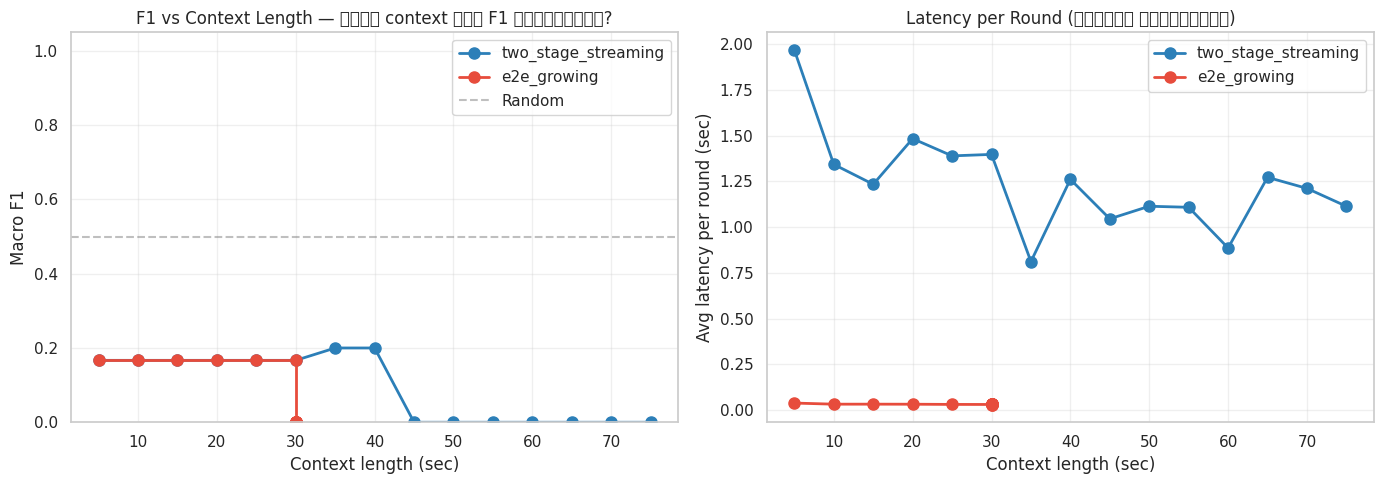

In [12]:
# === Section 6: Plot F1 + Latency evolution ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 evolution — F1 dev as context grows
for exp_name, color in [('two_stage_streaming', '#2c7fb8'), ('e2e_growing', '#e74c3c')]:
    sub = f1_df[f1_df.experiment == exp_name].sort_values('round')
    axes[0].plot(sub.context_sec, sub.macro_f1, 'o-', label=exp_name,
                 markersize=8, linewidth=2, color=color)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
axes[0].set_xlabel('Context length (sec)')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('F1 vs Context Length — ยิ่ง context มาก F1 ดีขึ้นไหม?')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

# Plot 2: Latency per round
for exp_name, color in [('two_stage_streaming', '#2c7fb8'), ('e2e_growing', '#e74c3c')]:
    sub = f1_df[f1_df.experiment == exp_name].sort_values('round')
    axes[1].plot(sub.context_sec, sub.avg_latency, 'o-', label=exp_name,
                 markersize=8, linewidth=2, color=color)
axes[1].set_xlabel('Context length (sec)')
axes[1].set_ylabel('Avg latency per round (sec)')
axes[1].set_title('Latency per Round (ต่อรอบ ไม่ใช่รวม)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/evolution.png', dpi=150, bbox_inches='tight')
plt.show()

=== Best per experiment ===


,experiment,strategy,macro_f1,test_set_f1,drop,avg_ttfd,avg_lat_per_round
4,e2e_growing,final,0.1667,0.9901,0.8234,NaN,0.0295
2,two_stage_streaming,any,0.5833,0.9958,0.4125,235.0,1.2376


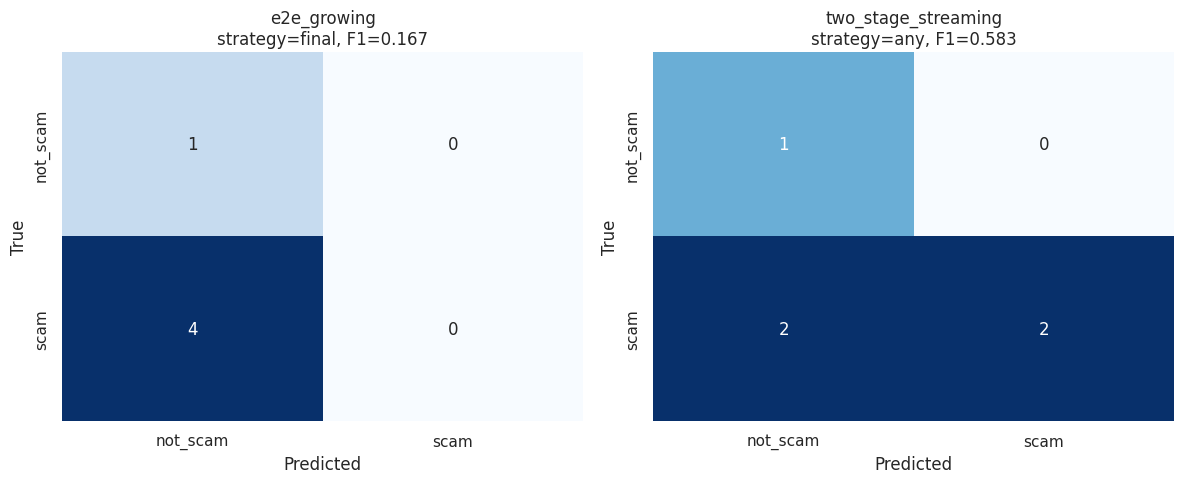

In [13]:
# === Section 7: Best per experiment + Confusion matrix ===
best = summary.loc[summary.groupby('experiment').macro_f1.idxmax()].copy()
best['model'] = best.experiment.apply(lambda x: 'two_stage' if 'two_stage' in x else 'e2e')
best['test_set_f1'] = best.model.map(TEST_SET_F1)
best['drop'] = best.test_set_f1 - best.macro_f1

print('=== Best per experiment ===')
display(best[['experiment', 'strategy', 'macro_f1', 'test_set_f1', 'drop',
              'avg_ttfd', 'avg_lat_per_round']].round(4))

# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (_, row) in zip(axes, best.iterrows()):
    exp_name = row.experiment
    strategy = row.strategy
    wdf = all_results[exp_name]
    calls = []
    for fn, group in wdf.groupby('filename'):
        calls.append({'true': int(group.true_label.iloc[0]),
                      'pred': aggregate(group, strategy)})
    cdf = pd.DataFrame(calls)
    cm = confusion_matrix(cdf.true, cdf.pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{exp_name}\nstrategy={strategy}, F1={row.macro_f1:.3f}')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/confusion.png', dpi=150, bbox_inches='tight')
plt.show()

{
  "config": {
    "chunk_sec": 5,
    "max_audio_sec": 30
  },
  "n_files": 5,
  "class_dist": {
    "1": 4,
    "0": 1
  },
  "best_experiment": "two_stage_streaming",
  "best_strategy": "any",
  "best_f1": 0.5833,
  "test_set_f1_ref": {
    "two_stage": 0.9958,
    "e2e": 0.9901
  },
  "generalization_gap": {
    "two_stage": 0.4125,
    "e2e": 0.8234
  },
  "latency_per_round": {
    "e2e_growing": 0.0295,
    "two_stage_streaming": 1.2376
  }
}


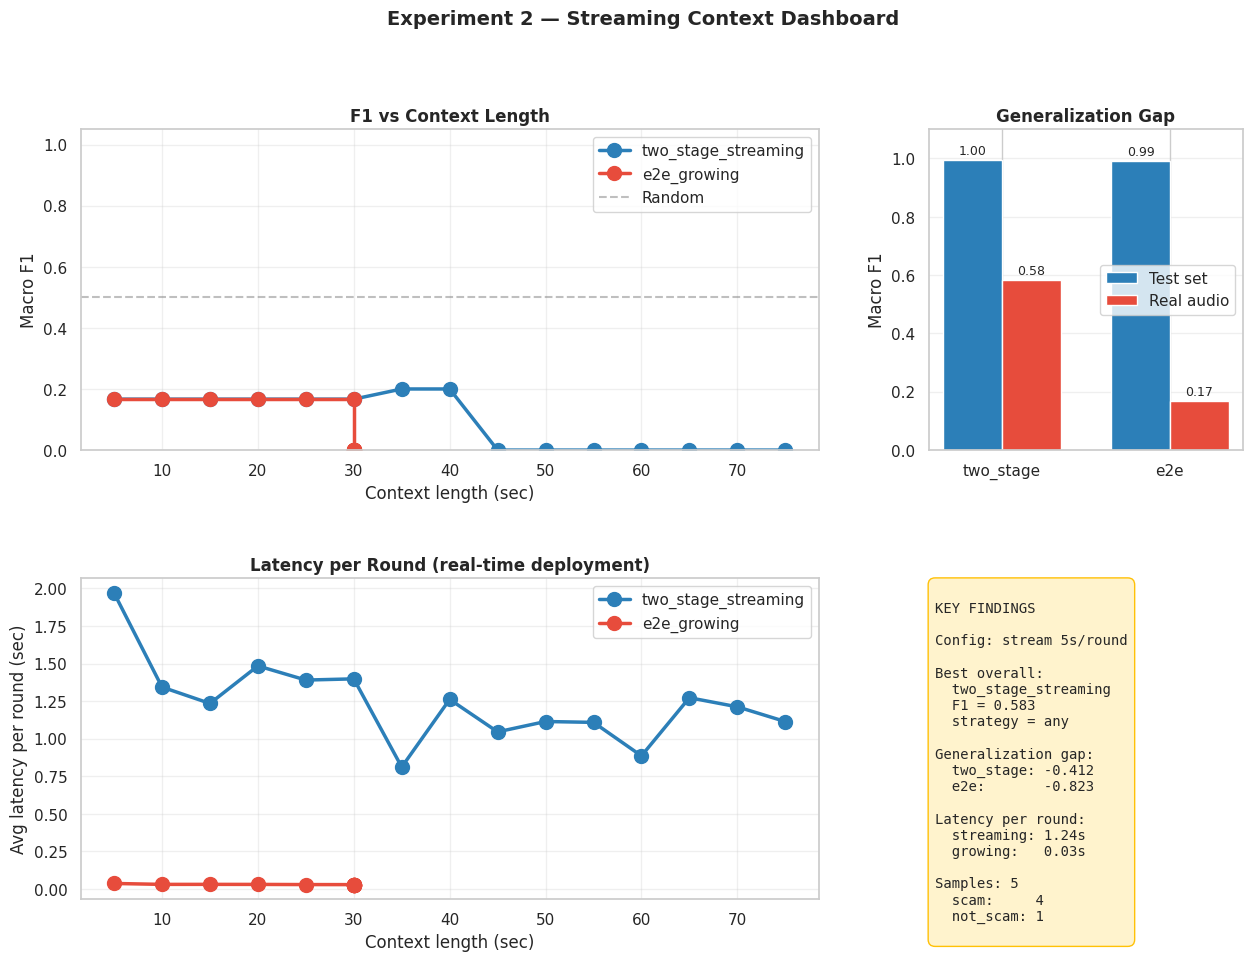


✅ Saved to /content/drive/MyDrive/ThaiScamCall/runs/experiment2/


In [14]:
# === Section 8: Save report + FINAL DASHBOARD ===
models_list = ['two_stage', 'e2e']
real_f1 = {m: best[best.model == m].macro_f1.max() for m in models_list}
best_overall = best.sort_values('macro_f1', ascending=False).iloc[0]

report = {
    'config': {'chunk_sec': CHUNK_SEC, 'max_audio_sec': MAX_AUDIO_SEC},
    'n_files': int(len(meta)),
    'class_dist': meta.label.value_counts().to_dict(),
    'best_experiment': best_overall.experiment,
    'best_strategy':   best_overall.strategy,
    'best_f1':         float(best_overall.macro_f1),
    'test_set_f1_ref': TEST_SET_F1,
    'generalization_gap': {m: float(TEST_SET_F1[m] - real_f1[m]) for m in models_list},
    'latency_per_round': {
        e: float(best[best.experiment == e].avg_lat_per_round.iloc[0])
        for e in best.experiment
    },
}
with open(f'{OUT_DIR}/report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print(json.dumps(report, indent=2, ensure_ascii=False))

# Dashboard
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# Panel 1: F1 evolution
ax1 = fig.add_subplot(gs[0, :2])
for exp_name, color in [('two_stage_streaming', '#2c7fb8'), ('e2e_growing', '#e74c3c')]:
    sub = f1_df[f1_df.experiment == exp_name].sort_values('round')
    ax1.plot(sub.context_sec, sub.macro_f1, 'o-', label=exp_name,
             markersize=10, linewidth=2.5, color=color)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax1.set_xlabel('Context length (sec)'); ax1.set_ylabel('Macro F1')
ax1.set_title('F1 vs Context Length', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1.05)

# Panel 2: Generalization gap
ax2 = fig.add_subplot(gs[0, 2])
test_list = [TEST_SET_F1[m] for m in models_list]
real_list = [real_f1[m] for m in models_list]
x_pos = np.arange(len(models_list)); width = 0.35
ax2.bar(x_pos - width/2, test_list, width, label='Test set', color='#2c7fb8')
ax2.bar(x_pos + width/2, real_list, width, label='Real audio', color='#e74c3c')
for i, (t, r) in enumerate(zip(test_list, real_list)):
    ax2.text(i - width/2, t + 0.02, f'{t:.2f}', ha='center', fontsize=9)
    ax2.text(i + width/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
ax2.set_xticks(x_pos); ax2.set_xticklabels(models_list)
ax2.set_ylabel('Macro F1'); ax2.set_title('Generalization Gap', fontweight='bold')
ax2.legend(); ax2.set_ylim(0, 1.1); ax2.grid(alpha=0.3, axis='y')

# Panel 3: Latency per round
ax3 = fig.add_subplot(gs[1, :2])
for exp_name, color in [('two_stage_streaming', '#2c7fb8'), ('e2e_growing', '#e74c3c')]:
    sub = f1_df[f1_df.experiment == exp_name].sort_values('round')
    ax3.plot(sub.context_sec, sub.avg_latency, 'o-', label=exp_name,
             markersize=10, linewidth=2.5, color=color)
ax3.set_xlabel('Context length (sec)'); ax3.set_ylabel('Avg latency per round (sec)')
ax3.set_title('Latency per Round (real-time deployment)', fontweight='bold')
ax3.legend(); ax3.grid(alpha=0.3)

# Panel 4: Summary text
ax4 = fig.add_subplot(gs[1, 2]); ax4.axis('off')
lat_two = best[best.experiment == 'two_stage_streaming'].avg_lat_per_round.iloc[0] if 'two_stage_streaming' in best.experiment.values else 0
lat_e2e = best[best.experiment == 'e2e_growing'].avg_lat_per_round.iloc[0] if 'e2e_growing' in best.experiment.values else 0

summary_text = f"""
KEY FINDINGS

Config: stream {CHUNK_SEC}s/round

Best overall:
  {best_overall.experiment}
  F1 = {best_overall.macro_f1:.3f}
  strategy = {best_overall.strategy}

Generalization gap:
  two_stage: -{TEST_SET_F1['two_stage'] - real_f1['two_stage']:.3f}
  e2e:       -{TEST_SET_F1['e2e'] - real_f1['e2e']:.3f}

Latency per round:
  streaming: {lat_two:.2f}s
  growing:   {lat_e2e:.2f}s

Samples: {len(meta)}
  scam:     {(meta.label==1).sum()}
  not_scam: {(meta.label==0).sum()}
"""
ax4.text(0.02, 0.98, summary_text, fontsize=10, family='monospace',
         verticalalignment='top', transform=ax4.transAxes,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd', edgecolor='#ffc107'))

fig.suptitle('Experiment 2 — Streaming Context Dashboard',
             fontsize=14, fontweight='bold', y=1.00)
plt.savefig(f'{OUT_DIR}/dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'\n✅ Saved to {OUT_DIR}/')

ทดสอบ 5 ไฟล์ (cap 120s/ไฟล์)...



rw_notscam03.mp3:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

rw_scam02.mp3:   0%|          | 0/24 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

...

rw_scam04.mp3:   0%|          | 0/15 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

rw_scam06.mp3:   0%|          | 0/12 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

=== ผล: accumulate text ไม่จำกัด ===
  Max context tested: 120s
  Max tokens reached: 337

🚩 BERT OVERFLOW เกิดขึ้นจริง!
   เริ่มเกิน 256 tokens ที่ context ~95s
   11/81 รอบ (14%) ถูก truncate
   Token หายไปสูงสุด: 81 tokens


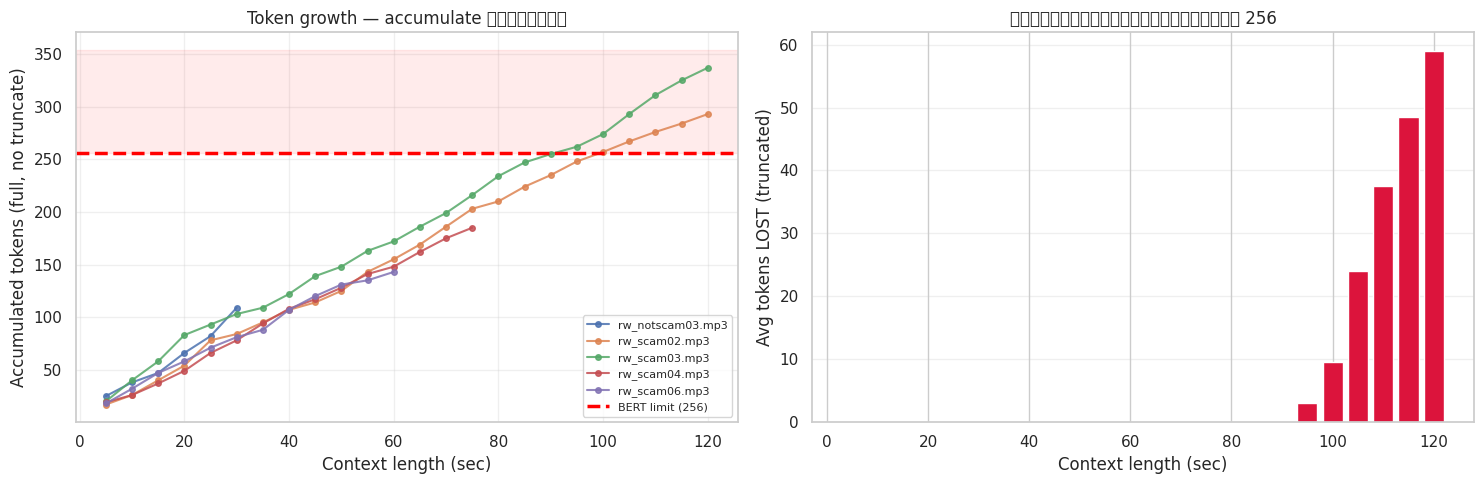


💡 สรุปสำหรับ mentor:
   - Context ≤ ~95s: ปลอดภัย (ไม่เกิน BERT limit)
   - เกิน ~95s: เริ่ม truncate → เสียข้อมูล
   → เลือก 15s ปลอดภัยแน่นอน (~46 tokens)


In [15]:
# === Section 9: BERT Token Overflow Test (หลักฐานว่าทำไมต้อง bound context) ===
# Accumulate text ไม่จำกัด บนเสียง TikTok จริง → ดูว่า context กี่วิ token เกิน 256
# (re-ASR ทีละ chunk + นับ token เต็ม ไม่ truncate)
BERT_LIMIT  = 256
MAX_TEST_SEC = 120   # cap เพื่อความเร็ว (พอเห็น overflow point)
print(f'ทดสอบ {len(meta)} ไฟล์ (cap {MAX_TEST_SEC}s/ไฟล์)...\n')
overflow_rows = []
for _, m in meta.iterrows():
    wav, _ = librosa.load(f'{REAL_AUDIO_DIR}/{m.filename}', sr=SR)
    duration = min(len(wav) / SR, MAX_TEST_SEC)
    accumulated = ''
    for start in tqdm(np.arange(0, duration - CHUNK_SEC + 0.1, CHUNK_SEC),
                      desc=m.filename[:18], leave=False):
        chunk = wav[int(start*SR):int((start+CHUNK_SEC)*SR)]
        accumulated = (accumulated + ' ' + asr_transcribe(chunk)).strip()
        n_full = len(text_tok(accumulated, truncation=False)['input_ids'])
        overflow_rows.append({
            'filename':      m.filename,
            'context_sec':   start + CHUNK_SEC,
            'n_tokens_full': n_full,
            'n_tokens_lost': max(0, n_full - BERT_LIMIT),
            'overflow':      n_full > BERT_LIMIT,
        })
udf = pd.DataFrame(overflow_rows)
udf.to_csv(f'{OUT_DIR}/bert_overflow_test.csv', index=False)
# สรุป
print('=== ผล: accumulate text ไม่จำกัด ===')
print(f'  Max context tested: {udf.context_sec.max():.0f}s')
print(f'  Max tokens reached: {udf.n_tokens_full.max()}')
ov = udf[udf.overflow]
if len(ov):
    print(f'\n🚩 BERT OVERFLOW เกิดขึ้นจริง!')
    print(f'   เริ่มเกิน {BERT_LIMIT} tokens ที่ context ~{ov.context_sec.min():.0f}s')
    print(f'   {len(ov)}/{len(udf)} รอบ ({len(ov)/len(udf)*100:.0f}%) ถูก truncate')
    print(f'   Token หายไปสูงสุด: {udf.n_tokens_lost.max()} tokens')
else:
    print(f'\n✅ ไม่มี overflow ในช่วงที่ test')
# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Plot 1: token growth ต่อไฟล์
for fn, grp in udf.groupby('filename'):
    grp = grp.sort_values('context_sec')
    axes[0].plot(grp.context_sec, grp.n_tokens_full, 'o-', markersize=4,
                 label=fn[:18], alpha=0.85)
axes[0].axhline(BERT_LIMIT, color='red', linestyle='--', linewidth=2.5,
                label=f'BERT limit ({BERT_LIMIT})')
axes[0].axhspan(BERT_LIMIT, udf.n_tokens_full.max()*1.05, color='red', alpha=0.08)
axes[0].set_xlabel('Context length (sec)')
axes[0].set_ylabel('Accumulated tokens (full, no truncate)')
axes[0].set_title('Token growth — accumulate ไม่จำกัด')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
# Plot 2: tokens lost ตาม context
ctx_lost = udf.groupby('context_sec').n_tokens_lost.mean()
axes[1].bar(ctx_lost.index, ctx_lost.values, width=CHUNK_SEC*0.8,
            color=['steelblue' if v == 0 else 'crimson' for v in ctx_lost.values])
axes[1].set_xlabel('Context length (sec)')
axes[1].set_ylabel('Avg tokens LOST (truncated)')
axes[1].set_title('ข้อมูลที่หายไปเพราะเกิน 256')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/bert_overflow_proof.png', dpi=150, bbox_inches='tight')
plt.show()
# จุดที่ปลอดภัย
safe_ctx = udf[~udf.overflow].context_sec.max() if (~udf.overflow).any() else 0
print(f'\n💡 สรุปสำหรับ mentor:')
print(f'   - Context ≤ ~{safe_ctx:.0f}s: ปลอดภัย (ไม่เกิน BERT limit)')
print(f'   - เกิน ~{ov.context_sec.min():.0f}s: เริ่ม truncate → เสียข้อมูล' if len(ov) else '')
print(f'   → เลือก 15s ปลอดภัยแน่นอน (~{udf[udf.context_sec==15].n_tokens_full.mean():.0f} tokens)' if (udf.context_sec==15).any() else '')